# 04 · Gold standards and the nonlinear transfer

Everything so far lived on a bench with closed forms. Real inference problems
are not this polite, so the last act removes the politeness while keeping the
control. The prior stays the same Gaussian field $g$. The observation becomes
nonlinear:

$$y = A\,\kappa(g) + \text{noise}, \qquad
\kappa(g) = \frac{e^{\lambda g - \lambda^2/2} - 1}{\lambda}.$$

**In words:** we observe a smoothed version of an exponentially warped field,
the kind of lopsided (lognormal) field that nonlinear structure formation
produces. The dial $\lambda$ sets the warp strength, and the normalization
keeps the warped field on the same scale at every $\lambda$. Two properties
make this the right substrate. First, at $\lambda \to 0$ it collapses back
to the exact bench, so correctness is testable at the flip of a dial. Second,
the posterior over $g$ is genuinely non-Gaussian, which is what everything
must now be measured against.

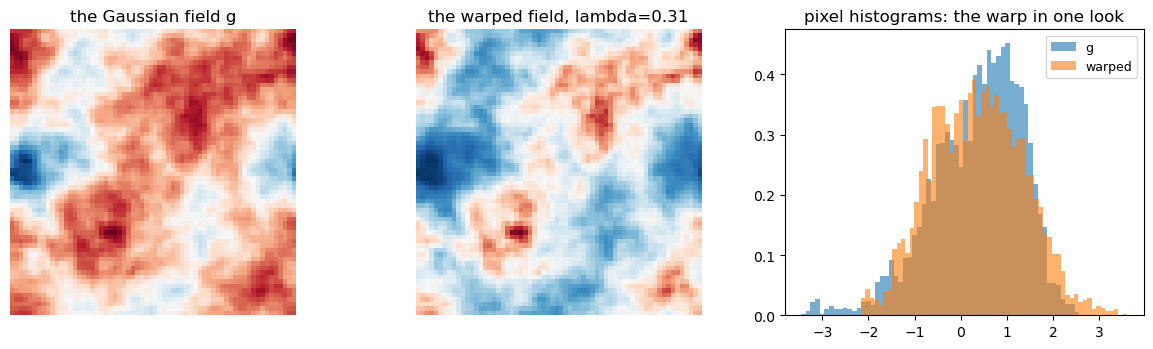

default lambda = 0.3143, chosen so the warped field's skewness is 1 (measured here: 0.08)


In [1]:
import json
import sys
from collections import defaultdict
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))
RES = ROOT / "results"

def rows(name):
    p = RES / name
    if not p.exists():
        print(f"({name} not found, cell skipped)")
        return []
    return [json.loads(l) for l in p.open()]

from tilt_audit import lognormal
from tilt_audit.fields import grid_to_z, make_basis, make_pk, unpack
import jax
import jax.numpy as jnp

n = 64
basis = make_basis(n)
Pz = jnp.asarray(grid_to_z(make_pk(basis), basis))
lam = lognormal.default_lambda()
g = jnp.sqrt(Pz) * jax.random.normal(jax.random.PRNGKey(3), Pz.shape)
gmap = np.asarray(unpack(g, basis))
kmap = np.asarray(lognormal.kappa(unpack(g, basis), lam))

fig, axes = plt.subplots(1, 3, figsize=(12, 3.6))
axes[0].imshow(gmap, cmap="RdBu_r")
axes[0].set_title("the Gaussian field g")
axes[1].imshow(kmap, cmap="RdBu_r")
axes[1].set_title(f"the warped field, lambda={lam:.2f}")
for ax in axes[:2]:
    ax.axis("off")
axes[2].hist(gmap.ravel(), bins=60, alpha=0.6, density=True, label="g")
axes[2].hist(kmap.ravel(), bins=60, alpha=0.6, density=True,
             label="warped")
axes[2].set_title("pixel histograms: the warp in one look")
axes[2].legend(fontsize=9)
plt.tight_layout()
plt.show()
skew = float(((kmap - kmap.mean()) ** 3).mean() / kmap.std() ** 3)
print(f"default lambda = {lam:.4f}, chosen so the warped field's skewness "
      f"is 1 (measured here: {skew:.2f})")

**Reading the panels.** Same underlying field, before and after the
warp. The histogram shows what the warp does: a heavy bright tail and a
compressed dark side, the signature of nonlinear structure. Real matter maps
look like the orange histogram, not the blue one.

## Gold standards, and their gates

On this substrate no formula gives the posterior, which is exactly the
situation practitioners face. The standard lament says proper validation is
too expensive. We measured the lament. A NUTS (Hamiltonian MCMC) gold
standard on the whitened parameterization of this posterior takes about
**74 seconds per 64x64 configuration** on one GPU, and it is not trusted
until it passes three gates.

1. **The dial test.** At $\lambda = 10^{-4}$ the sampler must reproduce the
   closed-form Wiener answer of notebook 01, per mode. It does, and the
   residual mean offsets scale linearly in $\lambda$ over two decades, which
   separates real nonlinear physics from sampler error.
2. **An independent referee.** At small warp both densities are known, so
   exact linear-posterior draws can be importance-reweighted into the
   nonlinear posterior with no MCMC at all. NUTS means agree with this
   closed-form construction with a z-score spread of 0.97, textbook
   agreement.
3. **Seed independence.** Two independently seeded runs agree per mode and in
   distribution (a two-sample test below its own split-null threshold).

The whole apparatus repeats at 128x128 (16,384 dimensions, 119 seconds). The
claim "offline validation is unaffordable" did not survive contact with the
measurement.

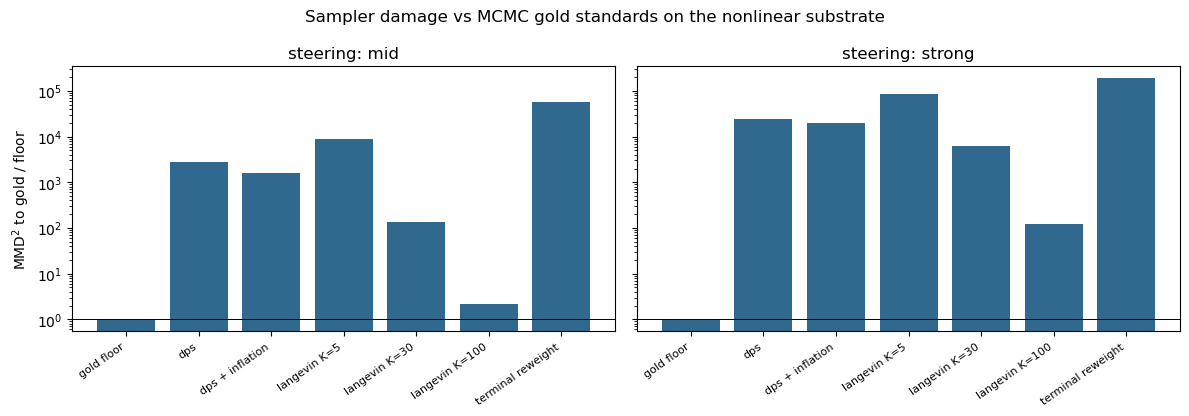

In [2]:
tra = [r for r in rows("transfer.jsonl") if r.get("n") == 64
       and r.get("space") != "kappa_z"
       and abs(r.get("lam", 0) - 0.3143) < 1e-3]
by = defaultdict(list)
for r in tra:
    by[(r["tilt"], r["sampler"])].append(r["mmd2"])
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2), sharey=True)
order = ["gold_floor", "dps", "dps_inflated", "remy5", "remy30", "remy100",
         "terminal_is"]
disp = {"remy5": "langevin K=5", "remy30": "langevin K=30",
        "remy100": "langevin K=100", "dps_inflated": "dps + inflation",
        "gold_floor": "gold floor", "terminal_is": "terminal reweight"}
for ax, tiltname in zip(axes, ("mid", "strong")):
    floor = abs(np.median(by.get((tiltname, "gold_floor"), [1e-12])))
    labels, vals = [], []
    for s in order:
        v = by.get((tiltname, s))
        if v:
            labels.append(disp.get(s, s))
            vals.append(max(np.median(v), floor / 10) / floor)
    ax.bar(range(len(vals)), vals, color="#31688e")
    ax.set_yscale("log")
    ax.axhline(1, color="k", lw=0.7)
    ax.set_xticks(range(len(labels)))
    ax.set_xticklabels(labels, rotation=35, ha="right", fontsize=8)
    ax.set_title(f"steering: {tiltname}")
axes[0].set_ylabel("MMD$^2$ to gold / floor")
fig.suptitle("Sampler damage vs MCMC gold standards on the nonlinear "
             "substrate")
plt.tight_layout()
plt.show()

**Reading the bars.** The distance is now a kernel two-sample distance
(MMD) to the gold-standard draws, floor-referenced exactly as before (the
floor is a held-out gold subsample of the same size). Plug-in guidance stays
badly off. The annealed-Langevin ladder is the one method that walks down to
the floor as its per-level correction budget K grows, and the next figure
shows that convergence directly.

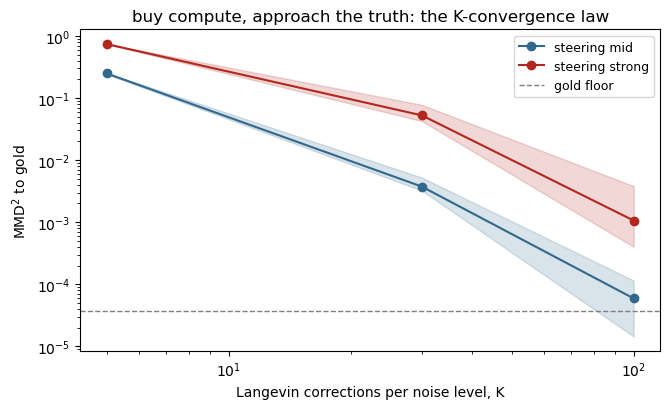

In [3]:
fig, ax = plt.subplots(figsize=(6.8, 4.2))
for tiltname, color in (("mid", "#31688e"), ("strong", "#b3261e")):
    Ks, med, lo, hi = [], [], [], []
    for K, name in ((5, "remy5"), (30, "remy30"), (100, "remy100")):
        v = by.get((tiltname, name), [])
        if v:
            Ks.append(K)
            med.append(np.median(v))
            lo.append(np.quantile(v, 0.25))
            hi.append(np.quantile(v, 0.75))
    ax.plot(Ks, med, "o-", color=color, label=f"steering {tiltname}")
    ax.fill_between(Ks, lo, hi, color=color, alpha=0.18)
fl = [abs(v) for v in by.get(("mid", "gold_floor"), [])]
if fl:
    ax.axhline(np.median(fl), color="gray", ls="--", lw=1,
               label="gold floor")
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("Langevin corrections per noise level, K")
ax.set_ylabel("MMD$^2$ to gold")
ax.set_title("buy compute, approach the truth: the K-convergence law")
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

## The decay law: which Gaussian-bench conclusions survive

One conclusion from the exact bench breaks here, and it breaks in the most
useful way possible: measurably, as a function of the realism dial. On the
Gaussian bench, adding the predicted-uncertainty term to plug-in guidance
(the missing term from notebook 02) makes it exact. On the warped substrate
that correction is only a linearization, and its value decays as the warp
grows. At skewness 1 it is not even reliable across observations: for some
observed skies it helps by 3.6x, for others it makes things worse.

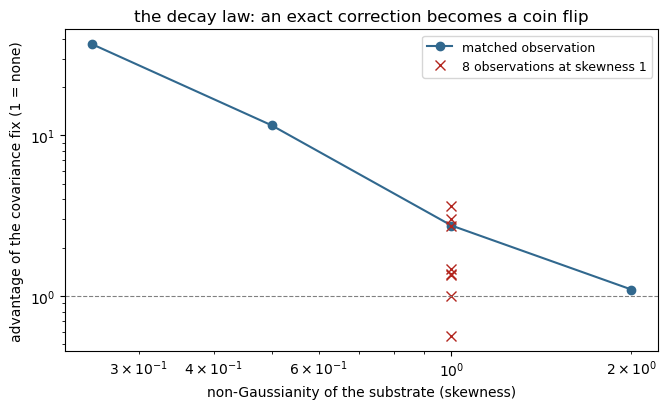

matched-observation ladder: 37.1x / 11.6x / 2.7x / 1.1x
across observations at skewness 1: median 1.42x, range 0.56x to 3.63x (below 1x = the fix hurt)


In [4]:
lam_rows = [r for r in rows("transfer.jsonl") if r.get("n") == 64
            and r.get("tilt") == "mid" and r.get("yseed") == 0
            and r.get("space") != "kappa_z"]
byl = defaultdict(lambda: defaultdict(list))
for r in lam_rows:
    byl[round(r["lam"], 3)][r["sampler"]].append(r["mmd2"])
pts = []
for lam_, skew in ((0.08, 0.25), (0.16, 0.5), (0.314, 1.0), (0.5, 2.0)):
    d = byl.get(lam_, {})
    if "dps" in d and "dps_inflated" in d:
        pts.append((skew, np.median(d["dps"]) / np.median(d["dps_inflated"])))

allr = [r for r in rows("transfer.jsonl") if r.get("n") == 64
        and r.get("tilt") == "mid" and r.get("space") != "kappa_z"
        and abs(r.get("lam", 0) - 0.3143) < 1e-3]
byy = defaultdict(lambda: defaultdict(list))
for r in allr:
    byy[r["yseed"]][r["sampler"]].append(r["mmd2"])
advs = sorted(np.median(d["dps"]) / np.median(d["dps_inflated"])
              for d in byy.values() if "dps" in d and "dps_inflated" in d)

fig, ax = plt.subplots(figsize=(6.8, 4.2))
ax.plot([p[0] for p in pts], [p[1] for p in pts], "o-", color="#31688e",
        label="matched observation")
ax.plot([1.0] * len(advs), advs, "x", color="#b3261e", ms=7,
        label="8 observations at skewness 1")
ax.axhline(1.0, color="gray", lw=0.8, ls="--")
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("non-Gaussianity of the substrate (skewness)")
ax.set_ylabel("advantage of the covariance fix (1 = none)")
ax.set_title("the decay law: an exact correction becomes a coin flip")
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()
print("matched-observation ladder: "
      + " / ".join(f"{p[1]:.1f}x" for p in pts))
print(f"across observations at skewness 1: median {np.median(advs):.2f}x, "
      f"range {advs[0]:.2f}x to {advs[-1]:.2f}x (below 1x = the fix hurt)")

**Reading the figure.** Blue: the same observed sky, warped
progressively harder. The correction's advantage falls two orders of
magnitude. Red crosses: at skewness 1, eight different observed skies. The
spread crosses 1, so whether the fix helps at all depends on the sky you
happen to have. The correction's exactness on the Gaussian bench was an
accident of that bench. The Langevin route's convergence, by contrast,
transfers untouched (previous figure), which is the practically important
asymmetry: refinement survives non-Gaussianity, clever closed-form
corrections do not.

## The last certificate standing, and its honest scope

One truth-free runtime check survived the whole audit in any form: run the
sampler at budget K and at 2K with fresh seeds, compare the two outputs with
a calibrated two-sample test, and treat agreement as convergence. Because
every run here is also compared to a gold standard, the bench can state
exactly what that check certifies.

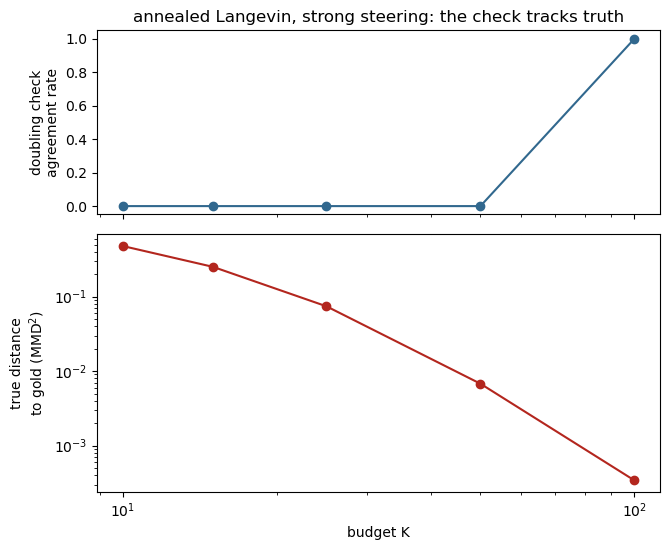

the boundary of validity, measured:

  plug-in guidance (converges to the WRONG answer):
    T=  64: doubling check agrees at rate 1.00 while the truth says badly wrong
    T= 128: doubling check agrees at rate 1.00 while the truth says badly wrong
    T= 256: doubling check agrees at rate 0.90 while the truth says badly wrong
    T= 512: doubling check agrees at rate 1.00 while the truth says badly wrong
  two runs stuck on the same island: agreement rate 1.00 (half the posterior missing)
  deterministic-ODE (flow matching) sampler: agreement 0.97
    at EVERY step count while sitting 63x above the gold floor


In [5]:
k2k = rows("k2k.jsonl")
byk = defaultdict(list)
for r in k2k:
    if r.get("arm") == "remy" and r.get("tilt") == "strong":
        byk[r["K"]].append((r["agree"], r["mmd2_to_gold"]))
Ks = sorted(byk)
fig, axes = plt.subplots(2, 1, figsize=(6.8, 5.6), sharex=True,
                         height_ratios=[1, 1.4])
ax = axes[0]
ax.plot(Ks, [np.mean([v[0] for v in byk[K]]) for K in Ks], "o-",
        color="#31688e")
ax.set_ylabel("doubling check\nagreement rate")
ax.set_ylim(-0.05, 1.05)
ax.set_title("annealed Langevin, strong steering: the check tracks truth")
ax = axes[1]
ax.plot(Ks, [np.median([v[1] for v in byk[K]]) for K in Ks], "o-",
        color="#b3261e")
ax.set_yscale("log")
ax.set_xscale("log")
ax.set_xlabel("budget K")
ax.set_ylabel("true distance\nto gold (MMD$^2$)")
plt.tight_layout()
plt.show()

byd = defaultdict(list)
for r in k2k:
    if r.get("arm") == "dps" and r.get("tilt") == "mid":
        byd[r["T"]].append((r["agree"], r["mmd2_to_gold"]))
print("the boundary of validity, measured:")
print()
print("  plug-in guidance (converges to the WRONG answer):")
for T in sorted(byd):
    ag = np.mean([v[0] for v in byd[T]])
    print(f"    T={T:4d}: doubling check agrees at rate {ag:.2f} "
          f"while the truth says badly wrong")
stuck = [r for r in k2k if r.get("arm") == "stuck"]
if stuck:
    print(f"  two runs stuck on the same island: agreement rate "
          f"{np.mean([r['agree'] for r in stuck]):.2f} "
          f"(half the posterior missing)")
nfe = rows("nfe2.jsonl")
if nfe:
    ags = np.mean([r["agree"] for r in nfe])
    m = np.median([r["mmd2_to_gold"] for r in nfe])
    fs = np.median([r["floor_scale"] for r in nfe])
    print(f"  deterministic-ODE (flow matching) sampler: agreement {ags:.2f}")
    print(f"    at EVERY step count while sitting {m/fs:.0f}x above the "
          f"gold floor")

**Reading the two panels.** Top: how often the truth-free doubling
check declares "converged". Bottom: the true distance to the gold standard.
For this sampler class the two move together, the check flags every
unconverged budget and passes the converged one. The printed lines below the
figure are the measured boundary of that validity: a sampler that converges
confidently to the wrong answer gets co-signed, two runs missing the same
island agree with each other, and for deterministic-ODE samplers the alarm
never fires at all. The honest scope is one-directional. **Disagreement
proves non-convergence, cheaply and with no ground truth. Agreement proves
nothing.**

## What a practitioner should actually do

Offline, build a matched synthetic bench for your problem, manufacture MCMC
gold standards on it (minutes, not weeks, as measured above), and run your
actual sampler against them with sample-space tests. Measure how your
conclusions decay as the bench's realism dial turns, the way the covariance
correction was measured above. At runtime, use the doubling check for its
alarm and never for its silence.

The full story, told slowly with every construction explained, is the blog
post at [andreastersenov.github.io/tilt-audit](https://andreastersenov.github.io/tilt-audit/).
The prediction ledger with every pre-registered expectation and its score is
`RESEARCH_LOG.md`.